### Error analysis using a IQR-based error matrix
- error matrix
    - identify values at Q25 and Q75
    - under-estimate (-1): < Q25
    - over-estimate (1): > Q75
    - accurate (0): in between Q25 and Q75

- correlation between country error distance and religious/geographic distance
    - country error distance: hamming/jaccard distance
    - religious/geographic distance: from exisiting file
    
- hierarchical clustering

In [1]:
import pickle, json
import pandas as pd 
from scipy import stats
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import cross_validate, cross_val_score
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from statsmodels.regression.mixed_linear_model import MixedLM, VCSpec


import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import pairwise_distances
import networkx as nx
from sklearn.metrics import silhouette_score
import geopandas as gpd
from sklearn.preprocessing import MinMaxScaler

import statsmodels.api as sm
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr


In [ ]:
# read country average data, get the countries and selected survey items
df_avg = pd.read_csv("./data/wvs7_country_avg.csv").set_index('Country')
items = list(df_avg.columns) # select the same items for the following dataframes
all_countries = list(df_avg.index)
df_avg.shape 

(66, 117)

In [ ]:
# read all individual wvs data
df_wvs = pd.read_csv("./data/wvs7_scaled.csv")[['Country'] + items].set_index('Country') 
df_wvs.shape 

(97220, 117)

In [ ]:
# LLM country representation
# make sure rows/countries and columns/items have consistent orders
df_gpt = pd.read_csv("./data/gpt_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries]
df_claude = pd.read_csv("./data/claude_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries]
df_deepseek = pd.read_csv("./data/deepseek_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries]

df_gpt.shape, df_claude.shape, df_deepseek.shape

((66, 117), (66, 117), (66, 117))

In [6]:
# set the current working model
df_llm = df_gpt # df_gpt, df_claude, df_deepseek
llm_name = "GPT" # GPT, Claude, DeepSeek

#### Load error matrix
- Central category based approach: 
    - categories in between 25% and 75% are central
- Load the error matrix constructed in 6.0_construct_error_matrix.ipynb

In [ ]:
with open("./data/df_outlier_byIQR_"+llm_name.lower()+".pkl", "rb") as f:
    df_outlier = pickle.load(f)

df_outlier.head()

,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
Andorra,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Argentina,0,0,0,0,0,0,0,0,1,0,...,0,1,0,1,0,1,0,0,0,0
Armenia,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Australia,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,-1,0,0
Bangladesh,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,1,0,0,0,0,1


### Do religious or geographically/religiously close countries have similar error patterns?
- pairwise country distance in error matrix
    - each LLM has its own error matrix
    - error distance measured as hamming distance from error matrix
    
- correlation between error distance with 
    - religious distance
    - geographic distance

In [ ]:
# map to country abbreviations
with open('./data/country_abr.json','r') as f:
    abr_map = json.load(f)

df_abr = pd.DataFrame(list(abr_map.items()), columns=["abr", "country"])
df_abr.head()

,abr,country
0,CAN,Canada
1,IDN,Indonesia
2,CHN,China
3,GBR,United Kingdom
4,USA,United States


In [ ]:
with open('./data/geo_distance.pkl', 'rb') as f:
    df_geo = pickle.load(f)
df_geo

,geo_dist,religious_dist,wv7_40d_dist,wv7_2d_dist,gpt35_40d_dist,gpt35_2d_dist,gpt4_40d_dist,gpt4_2d_dist,cld3_40d_dist,cld3_2d_dist,cld35_40d_dist,cld35_2d_dist,cld37_40d_dist,cld37_2d_dist
Andorra_Argentina,10528.427,0.609,0.941,0.521,2.102,0.053,2.087,1.070,1.442,0.288,2.417,1.431,1.389,0.378
Andorra_Armenia,3559.324,1.564,1.579,1.099,1.268,0.260,1.995,0.795,1.425,0.452,2.625,2.237,2.031,1.174
Andorra_Australia,17118.291,0.201,0.599,0.187,1.951,0.266,1.532,0.218,1.656,1.193,1.641,1.026,2.077,1.499
Andorra_Bangladesh,8166.538,1.894,1.947,1.359,1.408,0.178,2.546,2.104,1.602,0.608,3.084,2.646,2.254,1.573
Andorra_Bolivia,9659.274,1.363,1.405,1.023,1.531,0.156,2.498,1.224,1.521,0.391,2.965,2.441,2.124,1.393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Uzbekistan_Vietnam,4102.689,1.025,1.418,0.378,1.089,0.362,1.599,0.595,0.621,0.179,1.708,0.806,1.762,0.633
Uzbekistan_Zimbabwe,7663.527,0.471,1.213,0.502,1.269,0.519,0.694,0.028,1.634,1.260,1.772,0.056,1.033,0.135
Venezuela_Vietnam,16422.159,0.742,1.619,0.301,1.349,0.481,1.959,0.547,0.861,0.115,2.080,0.222,1.909,0.172
Venezuela_Zimbabwe,11188.674,0.754,1.047,0.489,1.303,0.273,1.272,0.642,1.674,1.292,1.881,0.912,1.020,0.454


In [9]:
country_to_abr = df_abr.set_index("country")["abr"].to_dict()

split_df = df_geo.index.to_series().str.split("_", n=1, expand=True)
df_distance = df_geo[["geo_dist", "religious_dist"]].copy().reset_index(drop=True)
df_distance["country1"] = split_df[0].map(country_to_abr).values
df_distance["country2"] = split_df[1].map(country_to_abr).values
df_distance = df_distance[["country1", "country2", "geo_dist", "religious_dist"]]
df_distance

,country1,country2,geo_dist,religious_dist
0,AND,ARG,10528.427,0.609
1,AND,ARM,3559.324,1.564
2,AND,AUS,17118.291,0.201
3,AND,BGD,8166.538,1.894
4,AND,BOL,9659.274,1.363
...,...,...,...,...
2140,UZB,VNM,4102.689,1.025
2141,UZB,ZWE,7663.527,0.471
2142,VEN,VNM,16422.159,0.742
2143,VEN,ZWE,11188.674,0.754


In [ ]:
df_relig = pd.read_csv('./data/religious_distance.csv')
df_relig_w7 = df_relig[df_relig["wave"] == 7.0][["country", "country2", "relig_diff"]]

df_distance = df_distance.merge(
    df_relig_w7.rename(columns={"country": "country1", "country2": "country2", "relig_diff": "relig_diff(7)"}),
    on=["country1", "country2"],
    how="left"
)
df_distance

,country1,country2,geo_dist,religious_dist,relig_diff(7)
0,AND,ARG,10528.427,0.609,NaN
1,AND,ARM,3559.324,1.564,NaN
2,AND,AUS,17118.291,0.201,NaN
3,AND,BGD,8166.538,1.894,NaN
4,AND,BOL,9659.274,1.363,NaN
...,...,...,...,...,...
2140,UZB,VNM,4102.689,1.025,0.848901
2141,UZB,ZWE,7663.527,0.471,1.052671
2142,VEN,VNM,16422.159,0.742,0.638902
2143,VEN,ZWE,11188.674,0.754,-1.097702


In [ ]:
# df_distance.to_csv("./data/distance.csv")

In [ ]:
df_distance = pd.read_csv("./data/distance.csv").drop(columns=["Unnamed: 0"])
df_distance.head()

,country1,country2,geo_dist,religious_dist,relig_diff(7),geo_dist_new
0,ARG,ARM,13413.133,0.955,0.726739,13828.698943
1,ARG,AUS,11728.788,0.409,-0.941264,13322.862927
2,ARG,BGD,16794.116,1.285,1.488444,17277.615129
3,ARG,BOL,1848.408,0.753,-1.435510,1872.454907
4,ARG,BRA,2350.728,0.623,-1.544145,2804.583188


In [11]:
def merge_distance(df_distance):

    country_to_abr = df_abr.set_index("country")["abr"].to_dict()

    # Hamming distance: proportion of positions where two rows differ
    hamming_norm = pairwise_distances(df_outlier, metric="hamming")

    df_hamming = pd.DataFrame(hamming_norm.astype(float),
                            index = all_countries, columns = all_countries)

    hamming_long = (
        df_hamming.stack()
        .rename("error_distance_hamming")
        .reset_index()
        .rename(columns={"level_0": "country1_name", "level_1": "country2_name"})
    )
    hamming_long["country1"] = hamming_long["country1_name"].map(country_to_abr)
    hamming_long["country2"] = hamming_long["country2_name"].map(country_to_abr)

    df_distance = df_distance.merge(
        hamming_long[["country1", "country2", "error_distance_hamming"]],
        on=["country1", "country2"],
        how="left"
    )

    df_distance['geo_dist_scaled'] = MinMaxScaler().fit_transform(df_distance[['geo_dist']])
    df_distance['religious_dist_scaled'] = MinMaxScaler().fit_transform(df_distance[['religious_dist']])

    return df_hamming, df_distance

In [12]:
df_hamming, df_distance = merge_distance(df_distance)
df_distance.head()

,country1,country2,geo_dist,religious_dist,relig_diff(7),geo_dist_new,error_distance_hamming,geo_dist_scaled,religious_dist_scaled
0,ARG,ARM,13413.133,0.955,0.726739,13828.698943,0.247863,0.672987,0.438822
1,ARG,AUS,11728.788,0.409,-0.941264,13322.862927,0.222222,0.587086,0.187672
2,ARG,BGD,16794.116,1.285,1.488444,17277.615129,0.299145,0.845416,0.590616
3,ARG,BOL,1848.408,0.753,-1.435510,1872.454907,0.247863,0.083189,0.345906
4,ARG,BRA,2350.728,0.623,-1.544145,2804.583188,0.256410,0.108808,0.286109


In [ ]:
def check_dist_correlation_hstack(df_distance, n_bins=10):
    panels = [
        ("religious_dist_scaled", "error_distance_hamming"),
        ("geo_dist_scaled",       "error_distance_hamming"),
    ]

    x_label_map = {
        'religious_dist_scaled': 'Religious distance (scaled)',
        'geo_dist_scaled':       'Geographic distance (scaled)',
    }
    y_label_map = {
        'error_distance_hamming': 'LLM error distance',
    }
    title_map = {
        'religious_dist_scaled': f'{llm_name}: Religious Distance vs. Error Distance',
        'geo_dist_scaled':       f'{llm_name}: Geographic Distance vs. Error Distance',
    }

    scatter_colors = {
        'religious_dist_scaled': '#a8c8e8',
        'geo_dist_scaled':       "#E9AF92",
    } # f4a582
    line_colors = {
        'religious_dist_scaled': 'steelblue',
        'geo_dist_scaled':       "#C55E4A",
    } # '#d6604d'
    legend_colors = {
        'religious_dist_scaled': '#2171b5',
        'geo_dist_scaled':       'brown',
    } # b2182b

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    rng = np.random.default_rng(42)

    for ax, (x_col, y_col) in zip(axes, panels):
        valid = df_distance[[x_col, y_col]].dropna().copy()
        r, p = pearsonr(valid[x_col], valid[y_col])

        valid['bin'] = pd.qcut(valid[x_col], q=n_bins, duplicates='drop')
        groups    = valid.groupby('bin', observed=True)
        bin_data  = [g[y_col].values for _, g in groups]
        bin_pos   = list(range(len(bin_data)))
        bin_means = [g[y_col].mean() for _, g in groups]

        pct_step   = 100 // n_bins
        q_labels   = [f"Q{i+1}" for i in range(len(bin_data))]
        pct_labels = [f"({i*pct_step}\u2013{(i+1)*pct_step}%)" for i in range(len(bin_data))]

        ax.boxplot(bin_data, positions=bin_pos, widths=0.5,
                   showfliers=False, patch_artist=True,
                   boxprops=dict(facecolor='white', linewidth=1.2),
                   medianprops=dict(color='black', linewidth=1.5),
                   whiskerprops=dict(linewidth=1.2),
                   capprops=dict(linewidth=1.2))

        for i, vals in enumerate(bin_data):
            jitter = rng.uniform(-0.18, 0.18, size=len(vals))
            ax.scatter(i + jitter, vals, color=scatter_colors[x_col], alpha=0.8, s=18, zorder=2,
                       label='Individual country pairs' if i == 0 else '')

        ax.plot(bin_pos, bin_means, color=line_colors[x_col], linewidth=2,
                marker='o', markersize=8, zorder=5, label='Mean in quantile bin')

        ax.set_xticks(bin_pos)
        ax.set_xticklabels(q_labels, fontsize=18)
        y_pct = ax.get_ylim()[0] - 0.03 * (ax.get_ylim()[1] - ax.get_ylim()[0])
        for pos, pct in zip(bin_pos, pct_labels):
            ax.text(pos, -0.12, pct, ha='center', va='bottom', fontsize=10,
                    transform=ax.get_xaxis_transform(), clip_on=False)
        ax.set_xlabel(x_label_map.get(x_col, x_col), fontsize=20, labelpad=20)
        ax.set_ylabel(y_label_map.get(y_col, y_col) if ax is axes[0] else '', fontsize=20)
        ax.set_ylim(bottom=0)
        ax.yaxis.grid(True, linestyle='--', linewidth=0.7, color='#cccccc')
        ax.set_axisbelow(True)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis='y', labelsize=15)
        print(x_label_map.get(x_col, x_col) + f" r = {r:.3f}, p = {p:.3f}")


    fig.suptitle('Correlation between '+llm_name+' Error Distance and Religious | Geographic Distance',
               fontsize=25, fontweight='bold', y=1.02)

    # shared legend: separate entries per panel color
    from matplotlib.lines import Line2D
    proxy_handles = [
        Line2D([0], [0], marker='o', linestyle='', color='#2171b5',
               markersize=7, alpha=0.9, label='Individual pairs (Religious)'),
        Line2D([0], [0], color='steelblue', linewidth=2, marker='o',
               markersize=6, label='Mean (Religious)'),
        Line2D([0], [0], marker='o', linestyle='', color='#C55E4A',
               markersize=7, alpha=0.9, label='Individual pairs (Geographic)'),
        Line2D([0], [0], color='#C55E4A', linewidth=2, marker='o',
               markersize=6, label='Mean (Geographic)'),
        # Line2D([0], [0], marker='o', linestyle='', color='#b2182b',
        #        markersize=7, alpha=0.9, label='Individual pairs (Geographic)'),
        # Line2D([0], [0], color='#d6604d', linewidth=2, marker='o',
        #        markersize=6, label='Mean (Geographic)'),
    ]
    fig.legend(handles=proxy_handles,
               loc='upper center', bbox_to_anchor=(0.5, 0.98),
               ncol=4, fontsize=18, frameon=False)

    # plt.savefig('./supfig/5_dist_hstack2_'+llm_name+'.pdf', dpi=300, bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()


Religious distance (scaled) r = 0.097, p = 0.000
Geographic distance (scaled) r = 0.004, p = 0.878


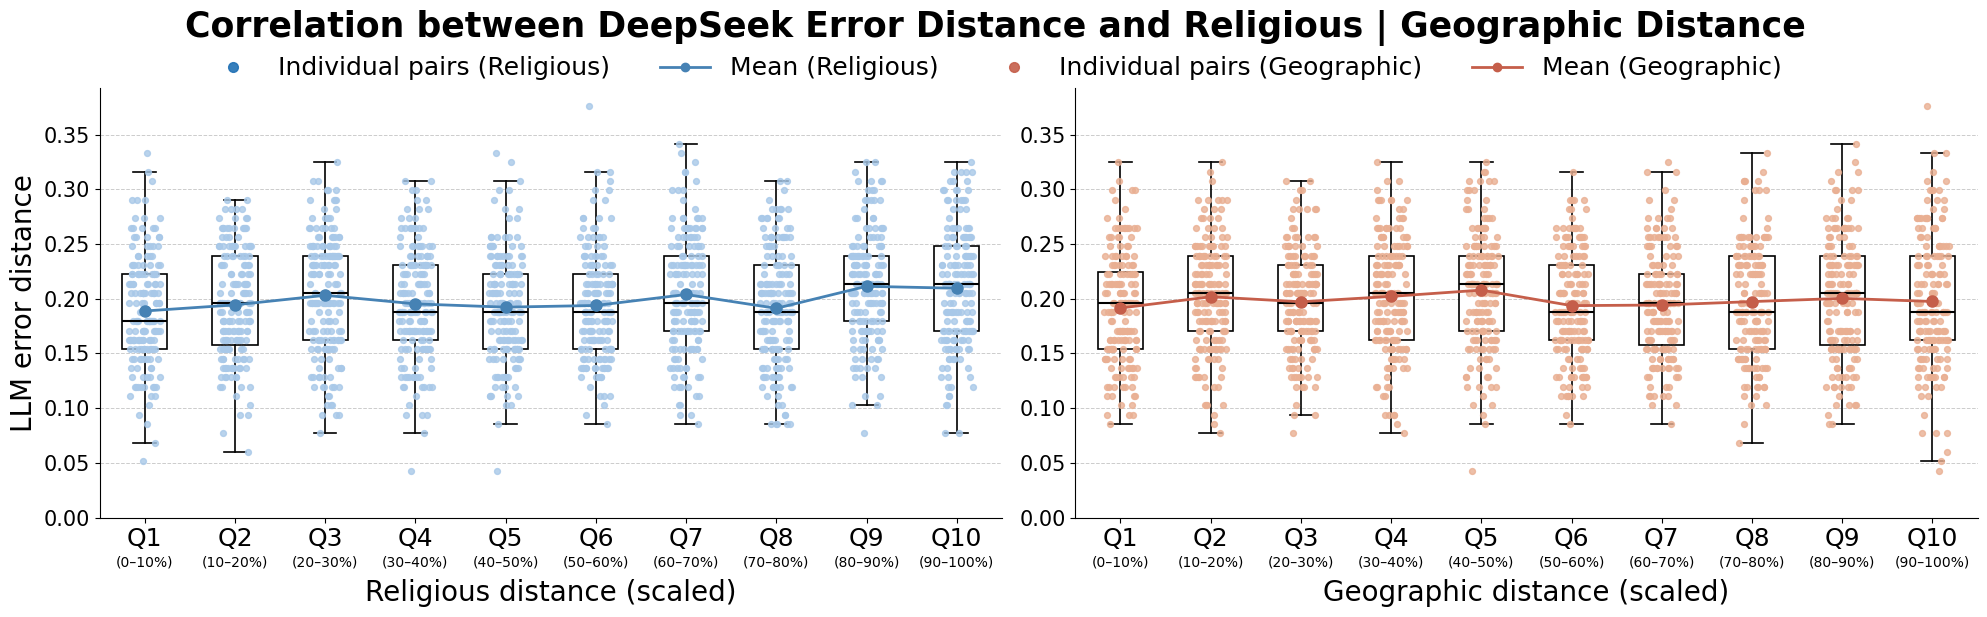

In [13]:
check_dist_correlation_hstack(df_distance)

#### Fit a linear mixed-effects model


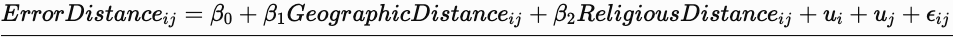

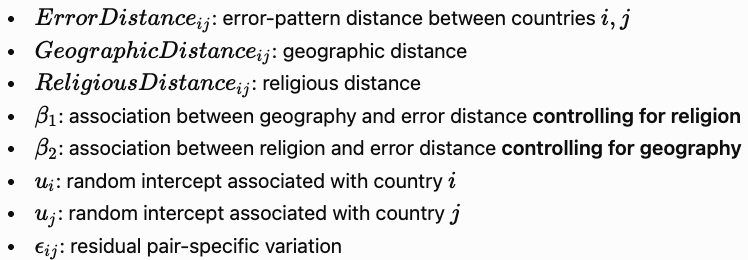

In [14]:
def fit_mixed_effect_model():
    
    cols = [
        "country1",
        "country2",
        "error_distance_hamming",
        "geo_dist_scaled",
        "religious_dist_scaled"
    ]

    d = df_distance[cols].dropna().copy()

   # construct the country random-effects matrix
    countries = sorted(set(d["country1"]) | set(d["country2"]))

    country_to_idx = {country: i for i, country in enumerate(countries)}

    n = len(d)
    C = len(countries)

    Z = np.zeros((n, C))

    # binary coding
    rows = np.arange(n)
    idx1 = d["country1"].map(country_to_idx).to_numpy()
    idx2 = d["country2"].map(country_to_idx).to_numpy()

    Z[rows, idx1] = 1
    Z[rows, idx2] = 1

    # define the shared country variance component
    vc = VCSpec(names=["country"], colnames=[[countries]], mats=[[Z]])

    # fit mixed effect model
    X = d[["geo_dist_scaled", "religious_dist_scaled"]].copy()
    X = sm.add_constant(X)

    groups = np.ones(n)

    model = MixedLM(
        endog=d["error_distance_hamming"],
        exog=X,
        groups=groups,
        exog_re=None,
        exog_vc=vc
    )

    result = model.fit(
        reml=True,
        method="lbfgs",
        maxiter=2000
    )   

    # print(result.summary())
    fixed_names = list(X.columns)

    ci = result.conf_int().loc[fixed_names]

    results_table = pd.DataFrame({
        "Estimate": result.fe_params,
        "SE": result.bse_fe,
        "z": result.fe_params / result.bse_fe,
        "p": result.pvalues.loc[fixed_names],
        "CI_lower": ci[0],
        "CI_upper": ci[1]
    })

    # print(results_table.round(4))
    # report the country random effect
    country_var = float(result.vcomp[0])
    country_sd = np.sqrt(country_var)

    residual_var = result.scale
    residual_sd = np.sqrt(residual_var)

    print(f"Country random-intercept variance = {country_var:.4f}")
    print(f"Country random-intercept SD       = {country_sd:.4f}")

    print(f"Residual variance = {residual_var:.4f}")
    print(f"Residual SD       = {residual_sd:.4f}")

    # calculate marginal and conditional R^2
    # fixed-effect predictions
    fixed_pred = X.to_numpy() @ result.fe_params.to_numpy()

    var_fixed = np.var(fixed_pred, ddof=1)

    # Variance contributed by random effects.
    # Each row has two country random intercepts.
    var_random = np.mean(
        np.sum(Z**2, axis=1)
    ) * country_var

    var_residual = result.scale

    var_total = (
        var_fixed +
        var_random +
        var_residual
    )

    r2_marginal = var_fixed / var_total

    r2_conditional = (
        var_fixed + var_random
    ) / var_total

    print(f"Marginal R²    = {r2_marginal:.3f}")
    print(f"Conditional R² = {r2_conditional:.3f}")

    # put all results into one report
    print(result.summary())

    print("\nFixed effects")
    print(results_table.round(4))

    print("\nRandom effects")
    print(f"Country variance: {country_var:.4f}")
    print(f"Country SD:       {country_sd:.4f}")
    print(f"Residual variance:{residual_var:.4f}")

    print("\nModel performance")
    print(f"Marginal R²:      {r2_marginal:.3f}")
    print(f"Conditional R²:   {r2_conditional:.3f}")


In [29]:
print(llm_name)
fit_mixed_effect_model()
# marginal R^2: variance explained by the fixed effects only; How much of the variation in error distance can be explained specifically by geographic distance and religious distance?
# conditional R^2: variance explained by the fixed effects + country random effects; How much variation can the entire model explain, including systematic differences associated with particular countries?

GPT
Country random-intercept variance = 0.0010
Country random-intercept SD       = 0.0317
Residual variance = 0.0010
Residual SD       = 0.0319
Marginal R²    = 0.063
Conditional R² = 0.685
               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: error_distance_hamming
No. Observations: 1711    Method:             REML                  
No. Groups:       1       Scale:              0.0010                
Min. group size:  1711    Log-Likelihood:     3334.0404             
Max. group size:  1711    Converged:          Yes                   
Mean group size:  1711.0                                            
---------------------------------------------------------------------
                       Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------------
const                  0.204     0.009  24.003  0.000   0.187   0.221
geo_dist_scaled        0.017     0.004   4.545  0.000   0.010  

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


#### Hierarchical clustering 
- similarity between country error profiles
- average-linkage: average distance between every observation in two clusters
- dendrogram

In [15]:
# visualize the distance distribution
def visualize_error_distance(df_hamming):
    values = df_hamming.values
    upper_tri = values[np.triu_indices(len(df_hamming), k=1)]

    print(pd.Series(upper_tri).describe().round(3))

    plt.figure(figsize=(4, 3))
    plt.hist(upper_tri, bins=25, rwidth=0.8)
    plt.xlabel("Hamming distance")
    plt.ylabel("Number of country pairs")
    plt.title(llm_name+ ": pairwise hamming distance (%.2f)" % values.mean())
    plt.show()

count    2145.000
mean        0.228
std         0.054
min         0.034
25%         0.188
50%         0.222
75%         0.265
max         0.419
dtype: float64


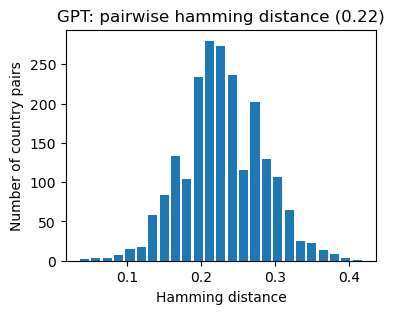

In [23]:
visualize_error_distance(df_hamming)

In [ ]:
def hc_dengrogram(df_hamming):
    # convert square matrix to condensed form
    condensed_distance = squareform(df_hamming.to_numpy(), checks=True)

    # average-linkage clustering 
    # average distance between every observation in cluster-A and cluster-B 
    Z_distance = linkage(condensed_distance, method="average") # average

    fig, ax = plt.subplots(figsize=(20, 8))

    dendro = dendrogram(
        Z_distance,
        labels=df_outlier.index.tolist(),
        leaf_rotation=90,
        leaf_font_size=15,
        color_threshold=0,
        above_threshold_color='steelblue',
        ax=ax
    )
    # recolor all dendrogram lines to steelblue
    for line in ax.get_lines():
        line.set_color('steelblue')
    ax.tick_params(axis='y', labelsize=18)

    # remove all spines except left
    for side in ['top', 'right', 'bottom']:
        ax.spines[side].set_visible(False)

    # Add the linkage distance above each merge
    for x_coordinates, y_coordinates in zip(
        dendro["icoord"],
        dendro["dcoord"]
    ):
        # Center of the horizontal merge line
        x = (x_coordinates[1] + x_coordinates[2]) / 2

        # Height of the merge
        y_val = y_coordinates[1]           # the actual merge distance to display
        y_pos = y_coordinates[1] - 0.008    # place text just above the merge line

        # ax.text(x, y_pos, f"{y_val:.2f}", ha="center", va="bottom", fontsize=8)

    ax.set_title(
        "Hierarchical Clustering of Countries Based on "+llm_name+" Misrepresentations\n",
        fontsize=25, fontweight="bold"
    )
    ax.set_ylabel("Pairwise Country Distance", fontsize=20)
    plt.tight_layout()
    
    # plt.savefig('./supfig/6_dendrogram_'+llm_name+'.pdf', dpi=300, bbox_inches='tight')
    
    plt.show()

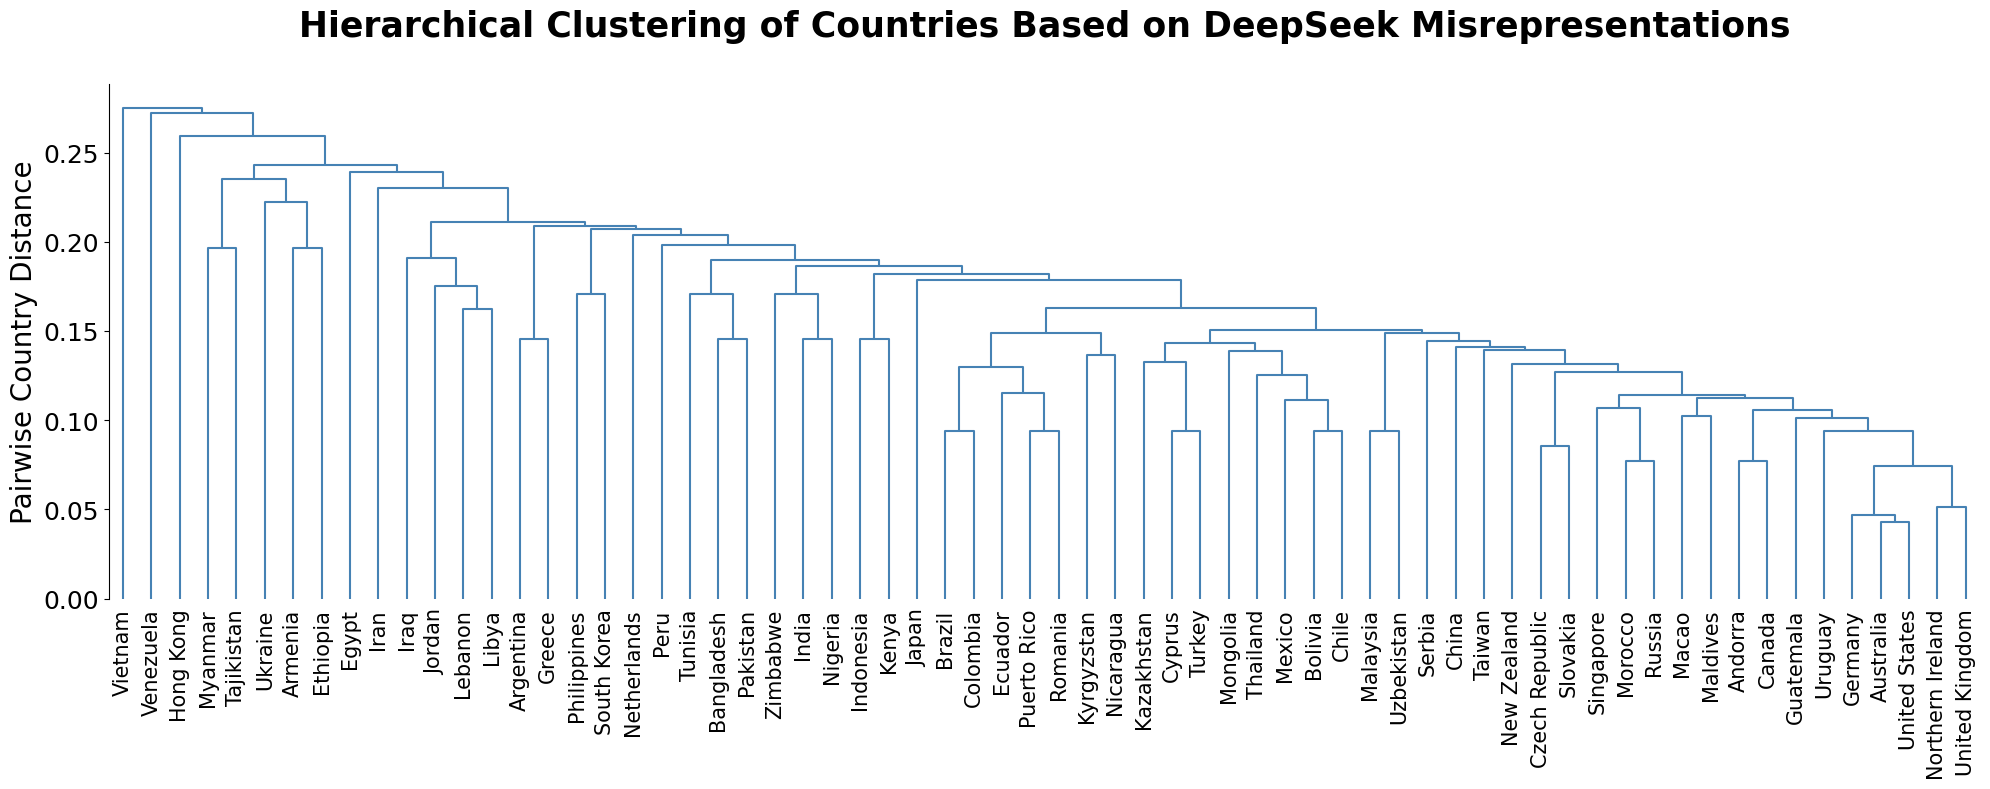

In [16]:
hc_dengrogram(df_hamming)

### Replicate results for Claude 

In [ ]:
# set the current working model
df_llm = df_claude 
llm_name = "Claude" 

with open("./data/df_outlier_byIQR_"+llm_name.lower()+".pkl", "rb") as f:
    df_outlier = pickle.load(f)

df_distance = pd.read_csv("./data/distance.csv").drop(columns=["Unnamed: 0"])

In [18]:
df_hamming, df_distance = merge_distance(df_distance)

Religious distance (scaled) r = 0.094, p = 0.000
Geographic distance (scaled) r = 0.095, p = 0.000


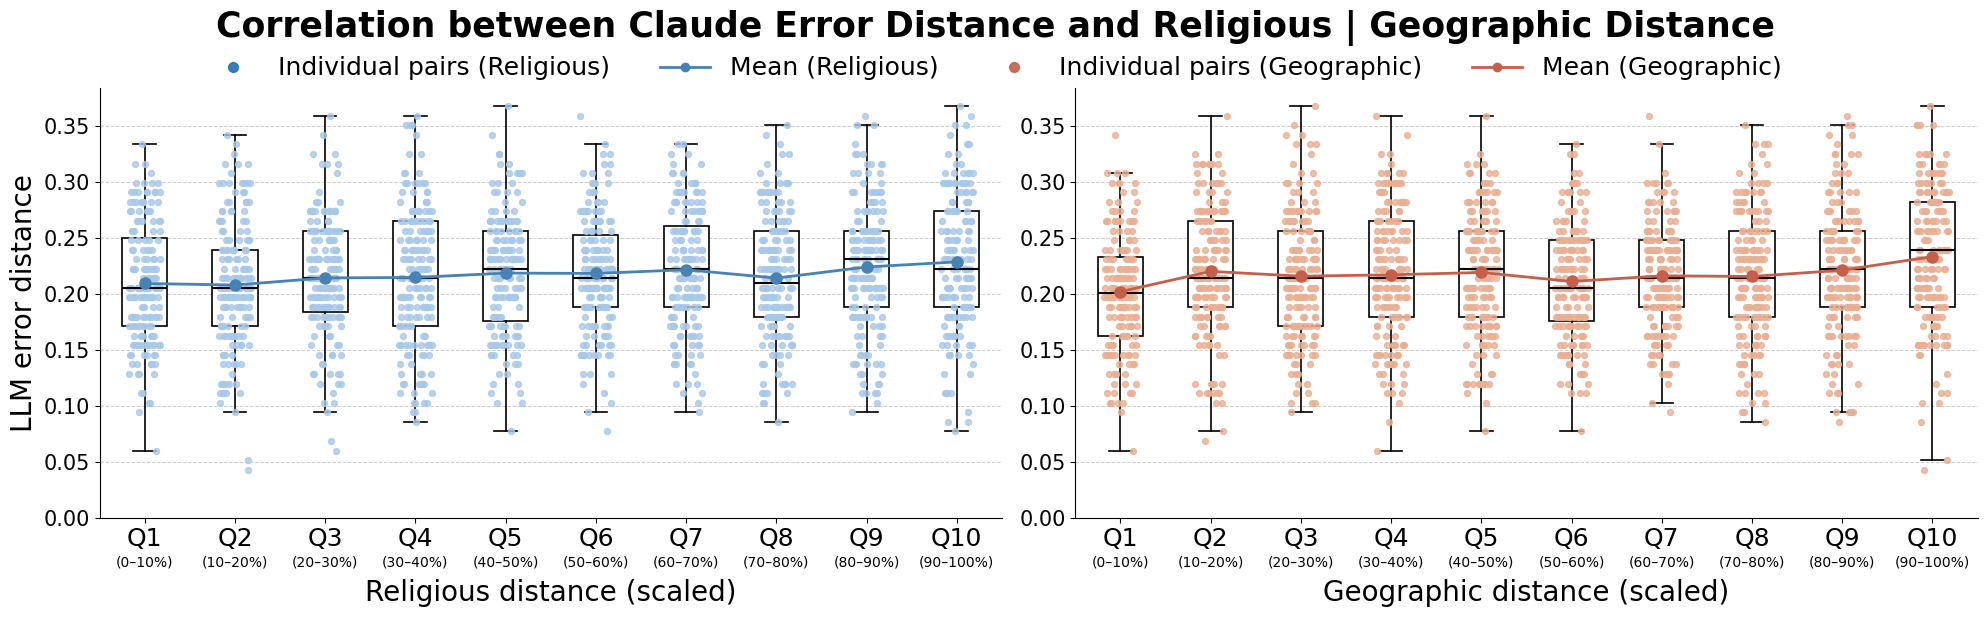

In [19]:
check_dist_correlation_hstack(df_distance)

In [20]:
print(llm_name)
fit_mixed_effect_model()

Claude
Country random-intercept variance = 0.0012
Country random-intercept SD       = 0.0344
Residual variance = 0.0008
Residual SD       = 0.0286
Marginal R²    = 0.052
Conditional R² = 0.756
               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: error_distance_hamming
No. Observations: 1711    Method:             REML                  
No. Groups:       1       Scale:              0.0008                
Min. group size:  1711    Log-Likelihood:     3508.9764             
Max. group size:  1711    Converged:          Yes                   
Mean group size:  1711.0                                            
---------------------------------------------------------------------
                       Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------------
const                  0.190     0.009  20.821  0.000   0.172   0.208
geo_dist_scaled        0.029     0.003   8.580  0.000   0.02

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


count    2145.000
mean        0.213
std         0.055
min         0.043
25%         0.179
50%         0.214
75%         0.256
max         0.368
dtype: float64


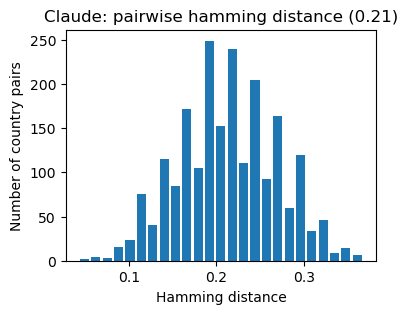

In [42]:
visualize_error_distance(df_hamming)

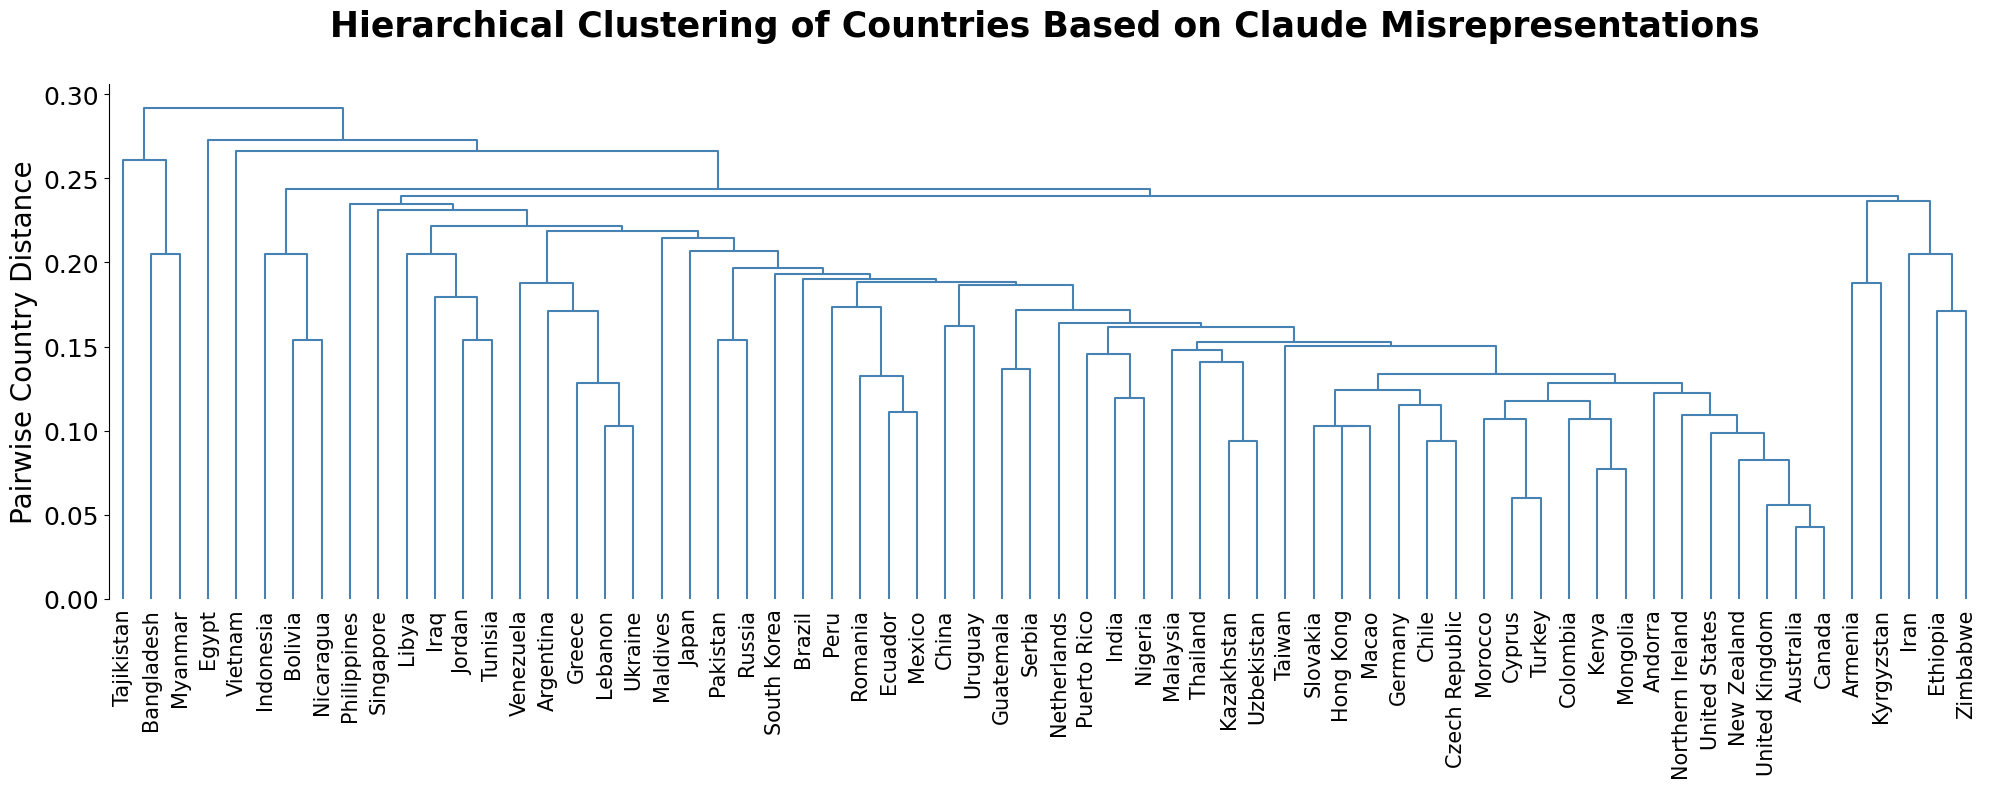

In [33]:
hc_dengrogram(df_hamming)

### Replicate results for DeepSeek

In [ ]:
# set the current working model
df_llm = df_deepseek 
llm_name = "DeepSeek" 

with open("./data/df_outlier_byIQR_"+llm_name.lower()+".pkl", "rb") as f:
    df_outlier = pickle.load(f)

df_distance = pd.read_csv("./data/distance.csv").drop(columns=["Unnamed: 0"])

In [35]:
df_hamming, df_distance = merge_distance(df_distance)

Religious distance (scaled) r = 0.097, p = 0.000
Geographic distance (scaled) r = 0.004, p = 0.878


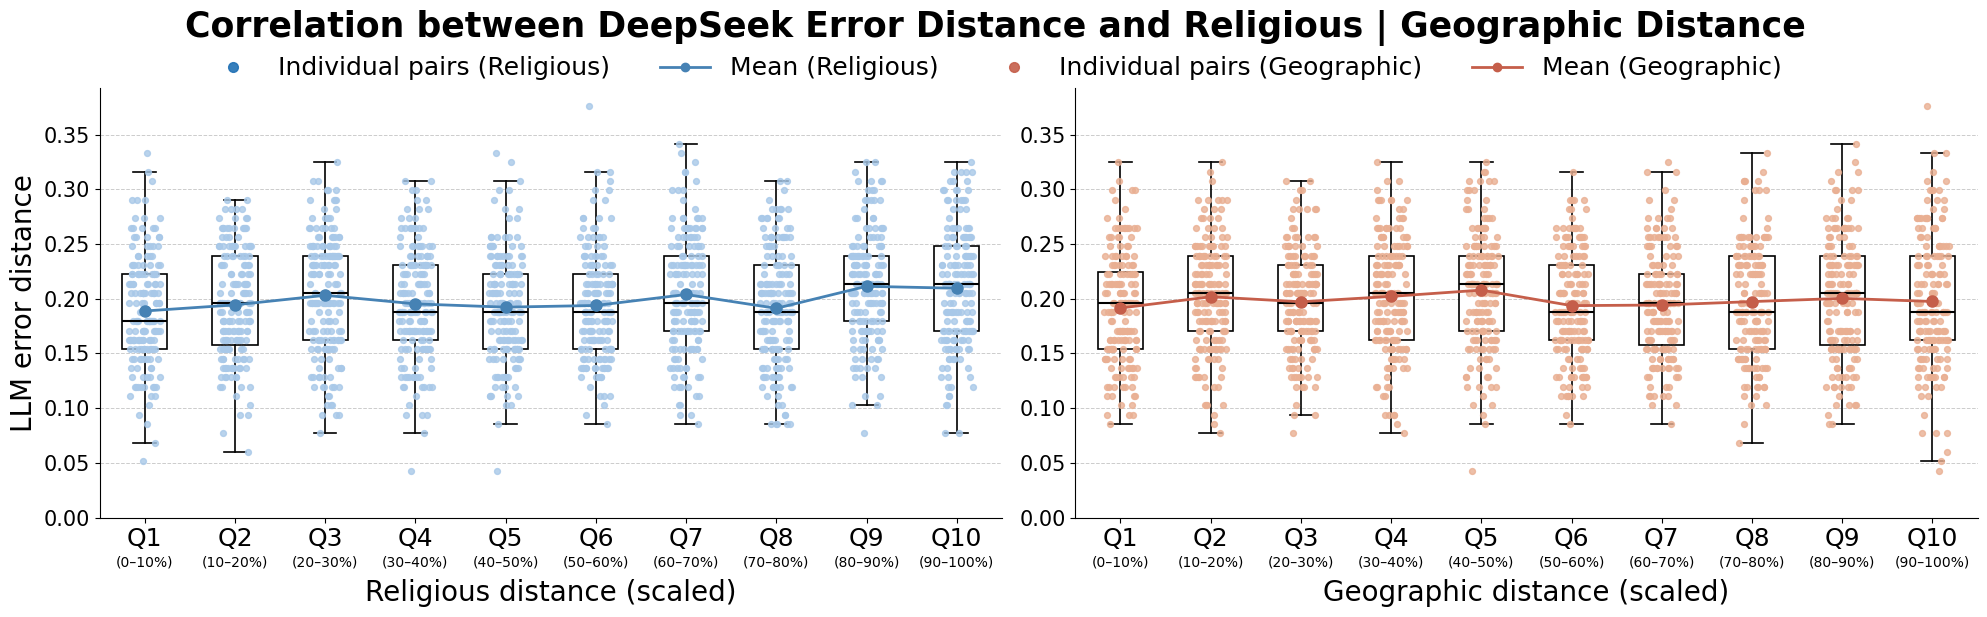

In [36]:
check_dist_correlation_hstack(df_distance)

In [47]:
print(llm_name)
fit_mixed_effect_model()

DeepSeek
Country random-intercept variance = 0.0010
Country random-intercept SD       = 0.0321
Residual variance = 0.0006
Residual SD       = 0.0255
Marginal R²    = 0.026
Conditional R² = 0.766
               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: error_distance_hamming
No. Observations: 1711    Method:             REML                  
No. Groups:       1       Scale:              0.0006                
Min. group size:  1711    Log-Likelihood:     3705.9274             
Max. group size:  1711    Converged:          Yes                   
Mean group size:  1711.0                                            
---------------------------------------------------------------------
                       Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------------
const                  0.182     0.009  21.425  0.000   0.166   0.199
geo_dist_scaled        0.013     0.003   4.469  0.000   0.

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


count    2145.000
mean        0.196
std         0.053
min         0.043
25%         0.154
50%         0.197
75%         0.231
max         0.376
dtype: float64


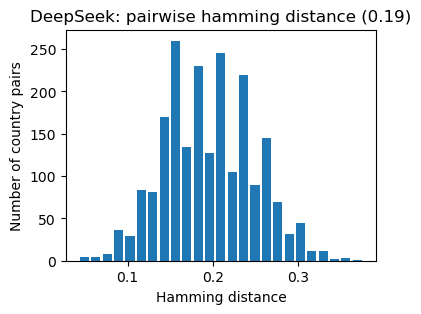

In [37]:
visualize_error_distance(df_hamming)

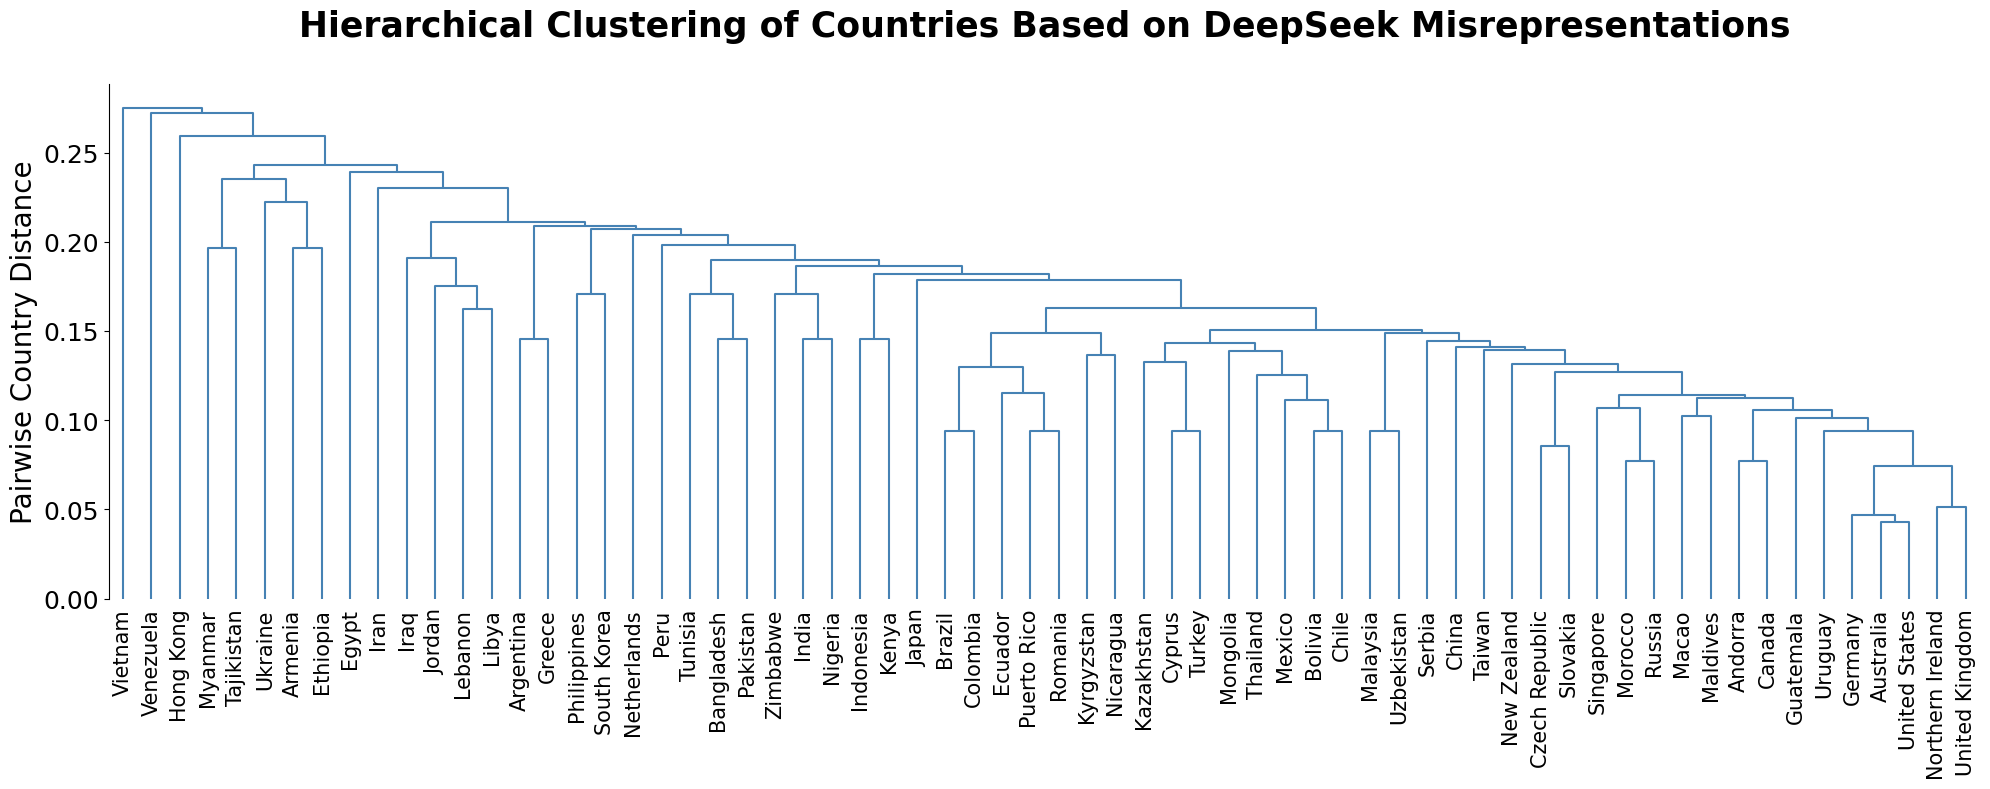

In [38]:
hc_dengrogram(df_hamming)

----------------------------------the end----------------------------------